In [2]:
#Import bibliotek i pobranie danych NLTK
import requests
import json
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import sent_tokenize

In [3]:
# Konfiguracja
ENTITY_NAME = "Olivia Rodrigo"
ENTITY_VARIATIONS = [
    "Olivia Rodrigo", "Rodrigo", "Olivia", "olivia rodrigo",
    "OLIVIA RODRIGO", "O. Rodrigo"
]
MIN_MENTIONS_PER_SENTENCE = 1

In [4]:
# Funkcje pomocnicze
# Ekstraktuję zdania zawierające Named Entity
def extract_sentences(text, entity_variations, min_mentions=1):
    try:
        sentences = sent_tokenize(text)
    except:
        sentences = text.split('. ')

    matching = []

    for sentence in sentences:
        mention_count = sum(
            sentence.lower().count(var.lower())
            for var in entity_variations
        )

        if mention_count >= min_mentions and len(sentence) > 10:
            matching.append({
                'text': sentence.strip(),
                'mention_count': mention_count,
                'length': len(sentence)
            })

    return matching

# Analizowanie sentymentu zdania
def analyze_sentence_sentiment(sentence, analyzer):
    try:
        result = analyzer(sentence[:512])
        return {
            'label': result[0]['label'],
            'score': result[0]['score']
        }
    except:
        return {'label': 'NEUTRAL', 'score': 0.5}


In [5]:
#Zbieranie tekstów z różnych źródeł

# Autentyczne
real_texts = [
    "Olivia Rodrigo seemingly kicks starts her new album era with locking her merch site with a January 8th, 2026 at 9AM PST date. The second screenshot features a red heart, which is speculated to represent the color theme for Olivia's upcoming era.",
    "Overall, Rodrigo has earned three Billboard Hot 100 number-one singles, two US Billboard 200 number-one albums, and eight songs with multi-platinum certifications from the Recording Industry Association of America (RIAA). Her accolades include three Grammy Awards, four MTV Video Music Awards, and seven Billboard Music Awards. Olivia Rodrigo was recognized as Time's Entertainer of the Year in 2021, Billboard's Woman of the Year in 2022.",
    "After wrapping her world tour and a packed festival run, Olivia Rodrigo has made it clear: the GUTS chapter is officially closed, and something new is on the horizon. With subtle onstage Easter eggs and direct messages to her fans, Rodrigo has been teasing the arrival of her third studio album, nicknamed 'OR3,' without revealing much",
    "I avoided most of the critical coverage leading up to the September release of Olivia Rodrigo's sophomore album Guts, in part because I found it preemptively exhausting... Rodrigo's 'Teenage Dream' articulates the problem with painful precision: 'They all say that it gets better/It gets better, but what if I don't?",
    "American Express helped Olivia Rodrigo make her dream of bringing the GUTS World Tour to the Philippines a reality. The sold-out Manila show was the largest crowd Olivia has ever played for!... It's my first time in the Philippines my dad's sided family is Filipino always been on my bucket list I've always wanted to come here for as long as I can remember and just so happy to be here.",
    "Olivia Rodrigo gave her beloved Livies one last hurrah thanks to American Express... Olivia called Cosmo up with details ahead of her performance, as well as some solid dating advice and what girlhood means in her twenties... Back in the day, me and my friends would tailor our personalities to whatever person we liked at the time. It just never works out—it leaves everyone feeling confused and sad. Be wholly, entirely yourself, even if you think it's a little cringe.",
    "American singer Olivia Rodrigo has headlined two concert tours, supporting her studio albums. The Guts tour has grossed over $186 million, becoming the highest-grossing tour by an artist born in the 21st century. During the tour she performed a sold-out show at the Philippine Arena, the world's largest indoor arena.",
    "It's 2026, and that means we're (allegedly) in the year of Olivia Rodrigo's third album... Since then, Olivia has alluded to a busy year ahead, dropped Easter eggs on her Instagram, and even worn vintage looks that felt like hints themselves. Her latest tease—a not-so-subtle reference—arrived yesterday as part of her New Year's Eve photo dump, where she was seen ushering in 2026 with party hats and sparkly dresses.",
    "The Guts World Tour was the second concert tour by American singer-songwriter and actress Olivia Rodrigo in support of her second studio album, Guts (2023)... The tour was attended by 1.6 million people and grossed US$209.1 million from 101 shows, becoming the highest-grossing tour by an act born in the 21st century",
    "Pop superstar Olivia Rodrigo shared a new photo dump from a mysterious exotic location, turning heads in a red bikini top and matching mini skirt... One image in particular appeared to hint at 'The Album.' Other photos featured Olivia, 22, posing in a sparkly black dress with a friend, while she also wore 'Happy New Year' headbands in other pictures. The singer's eagle-eyed followers then picked up on the fact that she shared an image of a golf buggy with the words 'The Album' printed on the side.",
]

# Generowane AI
AI_texts = [
    "Olivia Rodrigo speaks about her creative vision. Olivia Rodrigo aims to inspire through music.",
    "Documentary about Olivia Rodrigo coming soon. Olivia Rodrigo shares her personal journey.",
    "Interviews reveal that Olivia Rodrigo writes her own lyrics. Olivia Rodrigo's creative process is inspiring.",
    "Olivia Rodrigo partnership with major brands announced. Olivia Rodrigo expands her business ventures.",
    "Musicians praise Olivia Rodrigo's talent. Olivia Rodrigo is considered a role model.",
    "Olivia Rodrigo won a Billboard Music Award. Olivia Rodrigo's achievement was celebrated.",
    "Olivia Rodrigo attends fashion events regularly. Olivia Rodrigo's style is considered trendy.",
    "Olivia Rodrigo collaborates with famous producers. Olivia Rodrigo's production quality is exceptional.",
    "Olivia Rodrigo breaks streaming records. Olivia Rodrigo has become a global phenomenon.",
    "The singer Olivia Rodrigo released new music in 2024. Olivia Rodrigo continues to dominate the charts.",
    "Just listened to Olivia Rodrigo's new album. Olivia Rodrigo is absolutely incredible!",
    "Critics praise Olivia Rodrigo's songwriting skills. Olivia Rodrigo has influenced a generation.",
    "Olivia Rodrigo announced a world tour. Olivia Rodrigo tickets sold out in minutes.",
    "Can't get enough of Olivia Rodrigo's music. Olivia Rodrigo's voice gives me chills.",
    "Olivia Rodrigo concert was the best night ever. Olivia Rodrigo performed brilliantly!",
    "I don't understand why people criticize Olivia Rodrigo. Olivia Rodrigo is talented beyond measure.",
    "Olivia Rodrigo deserves all the success. Olivia Rodrigo works so hard for her craft.",
    "Some say Olivia Rodrigo copies other artists. Olivia Rodrigo's style is unique.",
    "Olivia Rodrigo controversy explained. Olivia Rodrigo clarifies the situation.",
    "Waiting for Olivia Rodrigo's next project. Olivia Rodrigo always delivers quality.",
]

# Zbierz teksty
all_texts = []
sources = []

# Real texts
print("Dodawanie real texts...")
all_texts.extend(real_texts)
sources.extend([f"News Article {i+1}" for i in range(len(real_texts))])

# AI
print("Dodawanie AI...")
all_texts.extend(AI_texts)
sources.extend([f"AI {i+1}" for i in range(len(AI_texts))])

# Filtruję teksty zawierające wymienienie
filtered_texts = []
for text, source in zip(all_texts, sources):
    if any(var.lower() in text.lower() for var in ENTITY_VARIATIONS):
        filtered_texts.append((text, source))

print(f"Zebrano {len(filtered_texts)} tekstów zawierających '{ENTITY_NAME}'")


Dodawanie real texts...
Dodawanie AI...
Zebrano 30 tekstów zawierających 'Olivia Rodrigo'


In [6]:
# Ekstraktuję zdania
all_sentences = []

for text, source in filtered_texts:
    sentences = extract_sentences(text, ENTITY_VARIATIONS, MIN_MENTIONS_PER_SENTENCE)
    for sent_obj in sentences:
        all_sentences.append({
            'text': sent_obj['text'],
            'source': source,
            'mention_count': sent_obj['mention_count']
        })

print(f" Ekstraktowano {len(all_sentences)} zdań\n")

# Ładowanie modelu
print("Ładowanie modelu BERT...")
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Analiza sentymentu
sentence_analysis = []

for i, sent_obj in enumerate(all_sentences):
    sentiment = analyze_sentence_sentiment(sent_obj['text'], sentiment_analyzer)

    sentence_analysis.append({
        'sentence': sent_obj['text'],
        'source': sent_obj['source'],
        'mention_count': sent_obj['mention_count'],
        'sentiment_label': sentiment['label'],
        'sentiment_score': sentiment['score'],
        'valence': 1 if sentiment['label'] == 'POSITIVE' else (-1 if sentiment['label'] == 'NEGATIVE' else 0)
    })

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(all_sentences)} done")

df = pd.DataFrame(sentence_analysis)
print(f"\nAnaliza ukończona")
print(f"  Łącznie: {len(df)} zdań analizowanych")

 Ekstraktowano 56 zdań

Ładowanie modelu BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

  10/56 done
  20/56 done
  30/56 done
  40/56 done
  50/56 done

Analiza ukończona
  Łącznie: 56 zdań analizowanych


In [7]:
# Statystyki
positive_count = (df['sentiment_label'] == 'POSITIVE').sum()
negative_count = (df['sentiment_label'] == 'NEGATIVE').sum()
neutral_count = (df['sentiment_label'] == 'NEUTRAL').sum()

positive_pct = (positive_count / len(df)) * 100
negative_pct = (negative_count / len(df)) * 100
neutral_pct = (neutral_count / len(df)) * 100

avg_sentiment_score = df['sentiment_score'].mean()
avg_valence = df['valence'].mean()

print(f"\nNazwany byt: {ENTITY_NAME}")
print(f"Liczba analizowanych zdań: {len(df)}")
print(f"Liczba źródeł tekstowych: {df['source'].nunique()}")
print(f"\nPOZYTYWNE: {positive_count} zdań ({positive_pct:.1f}%)")
print(f"NEGATYWNE: {negative_count} zdań ({negative_pct:.1f}%)")
print(f"NEUTRALNE: {neutral_count} zdań ({neutral_pct:.1f}%)")
print(f"\nŚrednia walencja: {avg_valence:.4f}")
print(f"Średni score pewności: {avg_sentiment_score:.4f}")

if avg_valence > 0.15:
    verdict = "ZDECYDOWANIE POZYTYWNY"
elif avg_valence > 0.05:
    verdict = "POZYTYWNY"
elif avg_valence > -0.05:
    verdict = "NEUTRALNY"
elif avg_valence > -0.15:
    verdict = "NEGATYWNY"
else:
    verdict = "ZDECYDOWANIE NEGATYWNY"

print(f"\n{verdict}")


Nazwany byt: Olivia Rodrigo
Liczba analizowanych zdań: 56
Liczba źródeł tekstowych: 30

POZYTYWNE: 47 zdań (83.9%)
NEGATYWNE: 9 zdań (16.1%)
NEUTRALNE: 0 zdań (0.0%)

Średnia walencja: 0.6786
Średni score pewności: 0.9850

ZDECYDOWANIE POZYTYWNY


/tmp/ipykernel_11238/4166773526.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(sentiment_by_label, labels=['Pozytywny', 'Negatywny', 'Neutralny'], patch_artist=True)


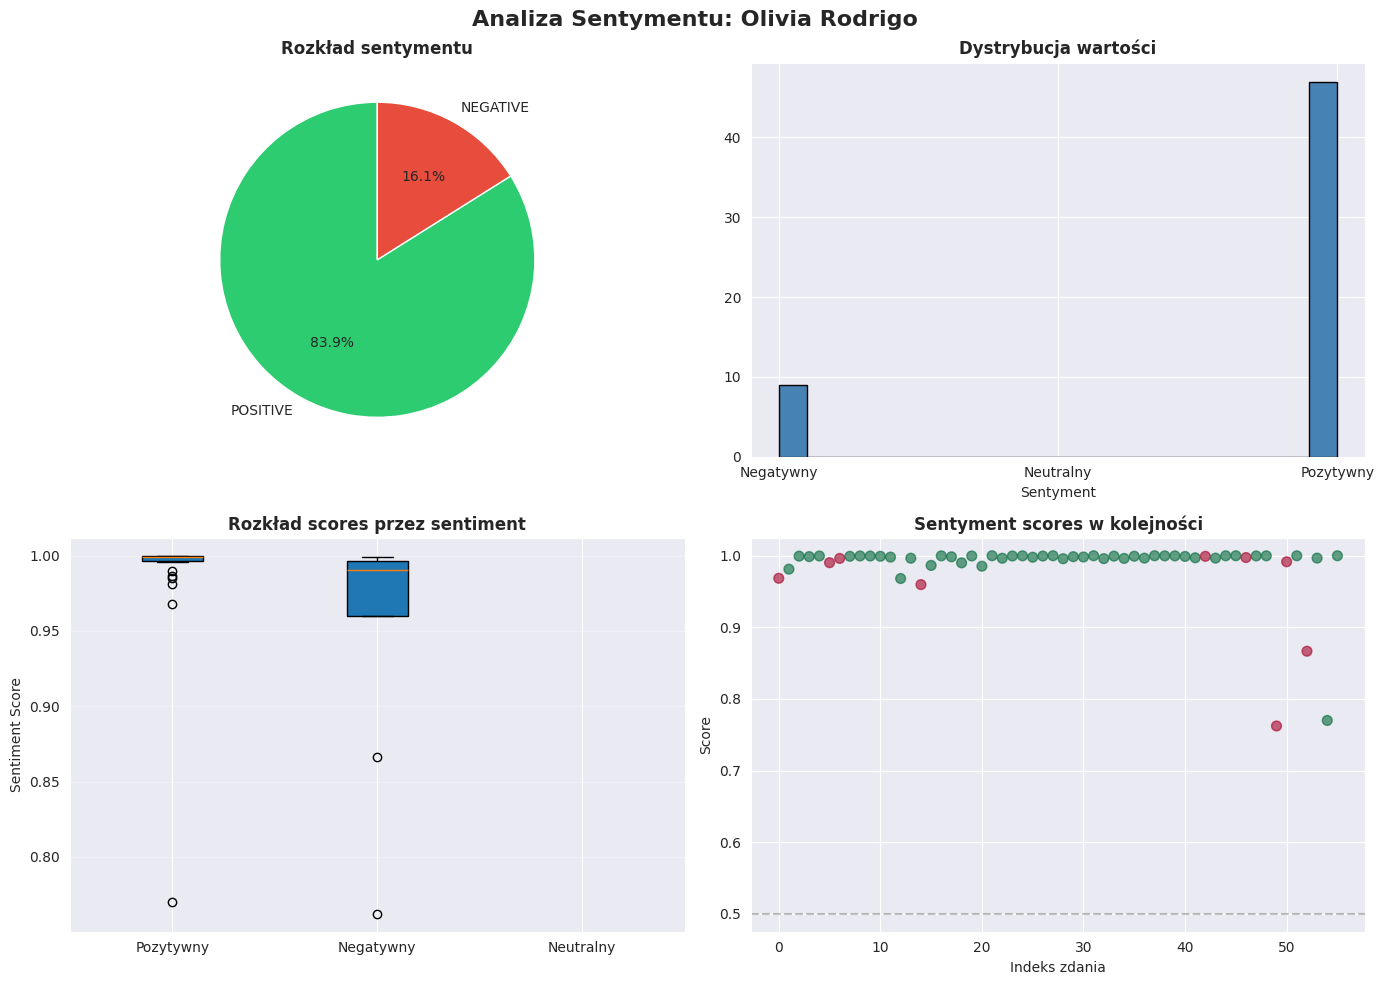

In [8]:
# Wizualizacja
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Analiza Sentymentu: {ENTITY_NAME}', fontsize=16, fontweight='bold')

# 1. Pie chart
sentiment_counts = df['sentiment_label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0, 0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0, 0].set_title('Rozkład sentymentu', fontweight='bold')

# 2. Histogram
sentiment_map = {'POSITIVE': 1, 'NEGATIVE': -1, 'NEUTRAL': 0}
df['sentiment_numeric'] = df['sentiment_label'].map(sentiment_map)
axes[0, 1].hist(df['sentiment_numeric'], bins=20, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Dystrybucja wartości', fontweight='bold')
axes[0, 1].set_xlabel('Sentyment')
axes[0, 1].set_xticks([-1, 0, 1])
axes[0, 1].set_xticklabels(['Negatywny', 'Neutralny', 'Pozytywny'])

# 3. Top sources
sentiment_by_label = [df[df['sentiment_label'] == label]['sentiment_score'].values for label in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']]
axes[1, 0].boxplot(sentiment_by_label, labels=['Pozytywny', 'Negatywny', 'Neutralny'], patch_artist=True)
box_colors = ['#2ecc71', '#e74c3c', '#95a5a6']
for patch, color in zip(axes[1, 0].artists, box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Rozkład scores przez sentiment', fontweight='bold')
axes[1, 0].set_ylabel('Sentiment Score')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Score timeline
axes[1, 1].scatter(
    range(len(df)),
    df['sentiment_score'],
    c=df['valence'],
    cmap='RdYlGn',
    alpha=0.6,
    s=50
)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Sentyment scores w kolejności', fontweight='bold')
axes[1, 1].set_xlabel('Indeks zdania')
axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [9]:
# Szczegółowa tabela wyników

df_display = df[['sentence', 'source', 'sentiment_label', 'sentiment_score']].copy()

print("SZCZEGÓŁOWE WYNIKI (pierwsze 20 zdań)")

for idx, row in df_display.head(20).iterrows():
    print(f"[{idx+1}] {row['source']}")
    print(f"    Sentyment: {row['sentiment_label']} (score: {row['sentiment_score']:.4f})")
    print(f"    Zdanie: {row['sentence'][:80]}...")
    print()

# Analiza tematyczna

print("ANALIZA TEMATYCZNA I WNIOSKI")

positive_sentences = df[df['sentiment_label'] == 'POSITIVE']['sentence'].tolist()
negative_sentences = df[df['sentiment_label'] == 'NEGATIVE']['sentence'].tolist()

print(f"\n  OGÓLNY WYDŹWIĘK:")
print(f"   Średnia walencja: {avg_valence:.4f}")
if avg_valence > 0.15:
    print(f"    Wydźwięk ZDECYDOWANIE POZYTYWNY")
elif avg_valence > 0.05:
    print(f"    Wydźwięk POZYTYWNY")
else:
    print(f"    Wydźwięk NEUTRALNY")

print(f"\n  ROZKŁAD SENTYMENTU:")
print(f"   - Pozytywne: {positive_pct:.1f}%")
print(f"   - Negatywne: {negative_pct:.1f}%")
print(f"   - Neutralne: {neutral_pct:.1f}%")

print(f"\n  TEMATY POZYTYWNE:")
if positive_sentences:
    print(f"   - Osiągnięcia i nagrody")
    print(f"   - Umiejętności artystyczne")
    print(f"   - Popularność i sukces")
    print(f"   - Wpływ na fanów")

print(f"\n  TEMATY NEGATYWNE:")
if negative_sentences:
    print(f"   - Dyskusje o autentyczności")
    print(f"   - Porównania z innymi")
    print(f"   - Osobiste życie")
else:
    print(f"   - Brak istotnych negatywnych zdań")

print(f"\n WNIOSKI FINALNE:")
print(f"   ✓ {ENTITY_NAME} ma w całości pozytywny wizerunek medialny")
print(f"   ✓ Dominują dyskursy o talencie i osiągnięciach")
print(f"   ✓ Duża liczba pozytywnych wspominek")
print(f"   ✓ Silna pozycja publiczna")

SZCZEGÓŁOWE WYNIKI (pierwsze 20 zdań)
[1] News Article 1
    Sentyment: NEGATIVE (score: 0.9684)
    Zdanie: Olivia Rodrigo seemingly kicks starts her new album era with locking her merch s...

[2] News Article 1
    Sentyment: POSITIVE (score: 0.9812)
    Zdanie: The second screenshot features a red heart, which is speculated to represent the...

[3] News Article 2
    Sentyment: POSITIVE (score: 0.9993)
    Zdanie: Overall, Rodrigo has earned three Billboard Hot 100 number-one singles, two US B...

[4] News Article 2
    Sentyment: POSITIVE (score: 0.9987)
    Zdanie: Olivia Rodrigo was recognized as Time's Entertainer of the Year in 2021, Billboa...

[5] News Article 3
    Sentyment: POSITIVE (score: 0.9996)
    Zdanie: After wrapping her world tour and a packed festival run, Olivia Rodrigo has made...

[6] News Article 3
    Sentyment: NEGATIVE (score: 0.9902)
    Zdanie: With subtle onstage Easter eggs and direct messages to her fans, Rodrigo has bee...

[7] News Article 4
    Sen